# Gene Window Chromatin Analysis
March 5, 2024

Examine the chromatin data around gene +1s to identify potential technical or biological reasons for enrichment at timepoints 60-70 and 130-140 minutes.

1. Collect MNase-seq data around gene +1s (computed separately)
    - Window of 3 kb
    - Flip if gene is a crick gene
2. Normalize the data based on length distribution.
    - "fix" csv file, removes the chromosome 12 ribosomal DNA reads.
3. Plot as a heatmap of all genes.
    - How do we plot these for all genes for all timepoints?


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Retrieving file: output/mnase/yl_rep1_mnase_reads/yl_rep1_mnase_reads_chr4.h5 from disk.
0/720 - 00:00:10.18
100/720 - 00:02:21.04
200/720 - 00:04:35.14
300/720 - 00:06:49.42
400/720 - 00:09:02.77
500/720 - 00:11:16.49
600/720 - 00:13:30.42
700/720 - 00:15:44.60
719/720 - 00:16:10.11
Retrieving file: output/mnase/yl_rep2_mnase_reads/yl_rep2_mnase_reads_chr4.h5 from disk.
0/720 - 00:16:24.70
100/720 - 00:19:12.09
200/720 - 00:21:59.71
300/720 - 00:24:48.10
400/720 - 00:27:37.02
500/720 - 00:30:25.74
600/720 - 00:33:14.46
700/720 - 00:36:04.49
719/720 - 00:36:36.80


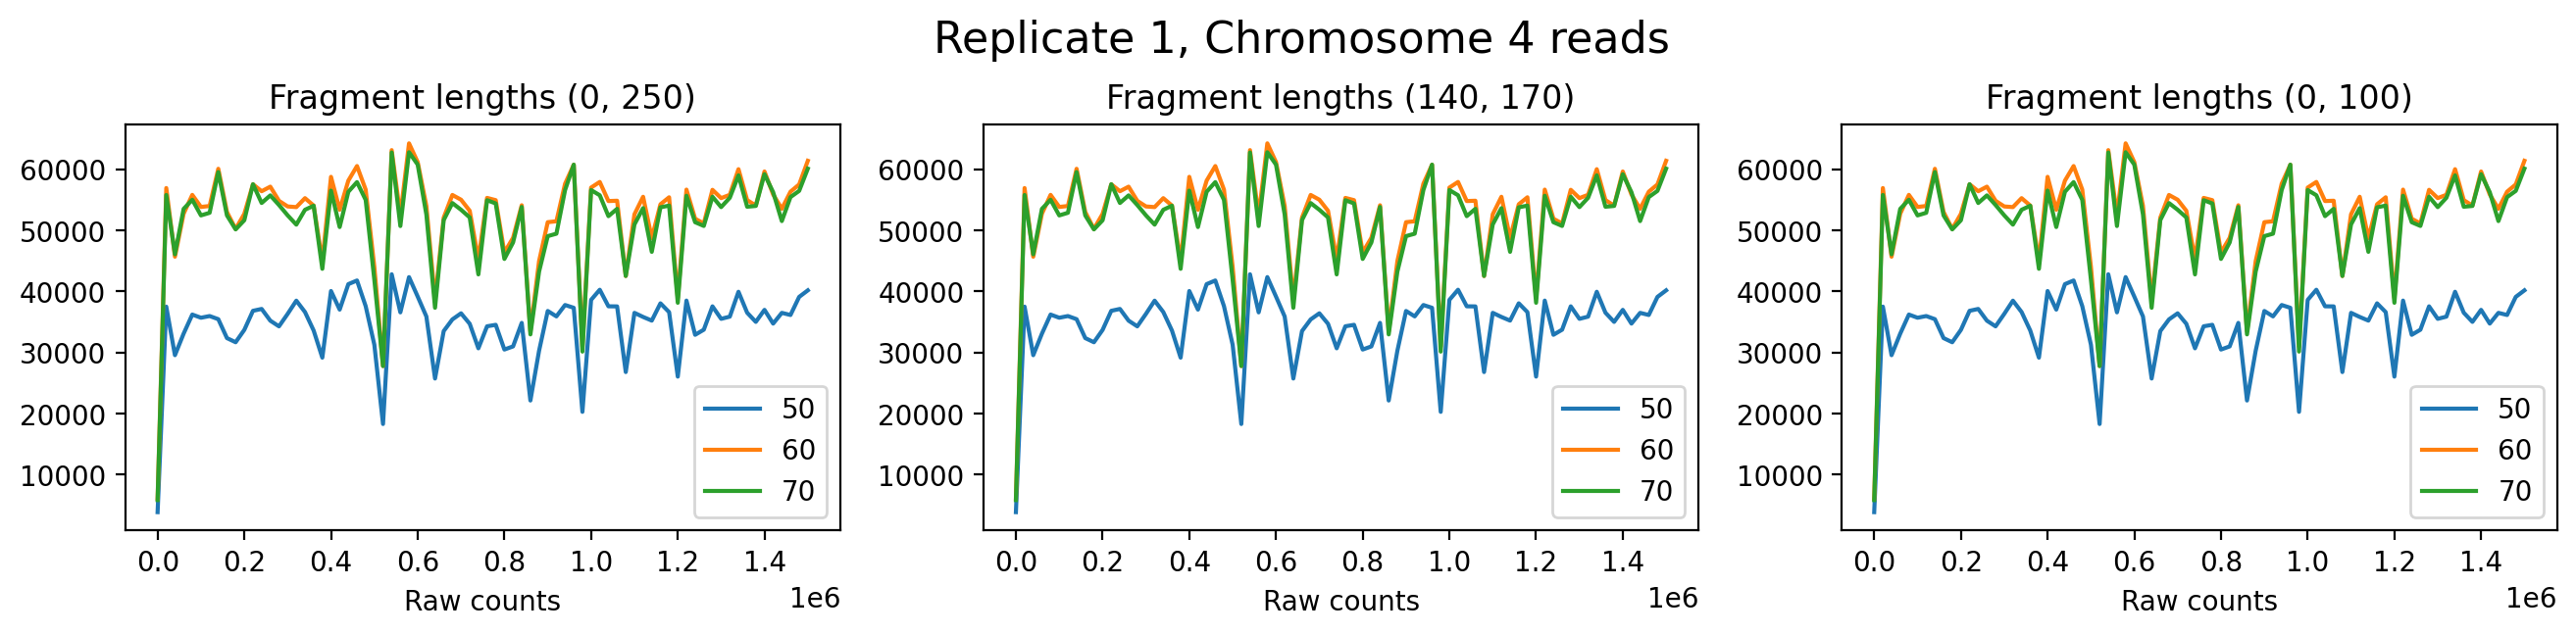

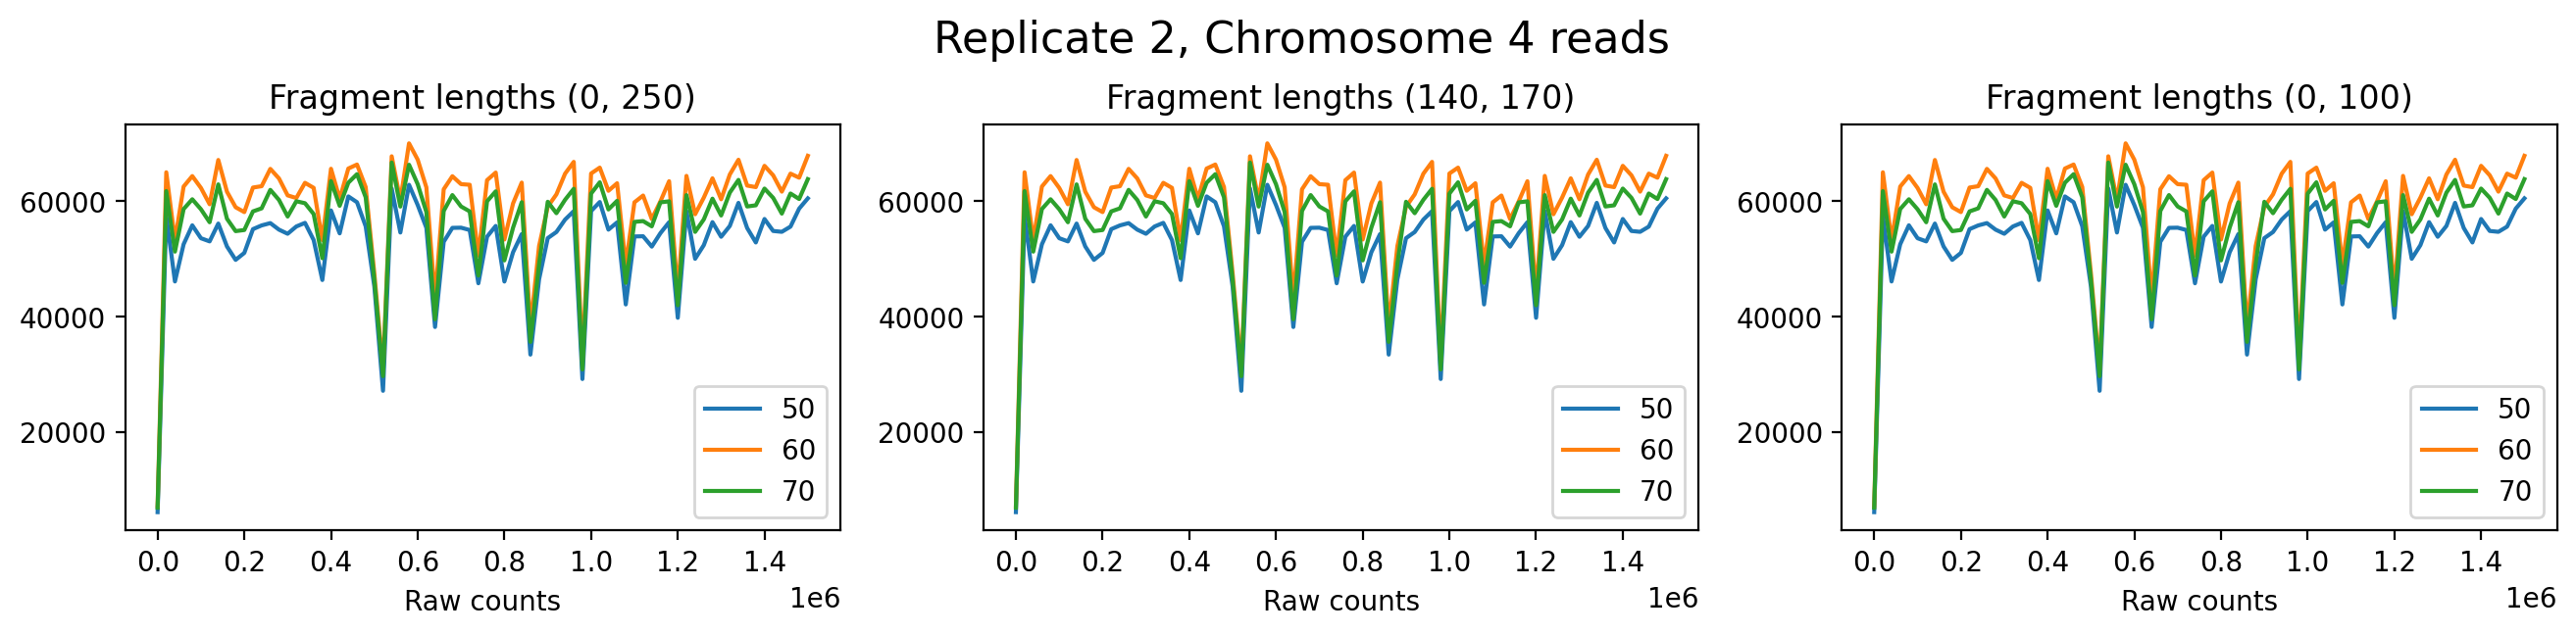

In [2]:
from cc_src.raw_chromatin_analysis import ChromatinDataAnalysis
from src.timer import Timer

timer = Timer()
chroms = [4] # [10, 3, 6, 5]

for chrom in chroms:
    for replicate in [1, 2]:
        analysis = ChromatinDataAnalysis()

        analysis.set_chrom_replicate(chromosome=chrom, replicate=replicate)
        analysis.create_gene_mnase_histogram(timer)
        analysis.normalize()

        analysis.plot_normalized_gene_sums()
        plt.savefig(f"output/raw_data_sum_analysis/chr{chrom}_rep{replicate}.png", dpi=150)
        plt.close()
        
        analysis.plot_genomic_chrom_counts()
        plt.savefig(f"output/raw_data_sum_analysis/60min_analysis_chr{chrom}_rep{replicate}.png", dpi=150)
